ML Model Selected
----
After evaluating several classification algorithms—including Decision Trees, Random Forests, Gradient Boosting, AdaBoost, and XGBoost—Logistic Regression was selected as the final model for predicting heart disease.

This choice was guided by the model’s consistently high recall and good overall accuracy on both the training and test sets. Although its precision is lower than ideal, it still outperforms most tree-based models in this respect.

In medical applications such as heart disease prediction, maximizing recall is crucial, since missing a true positive case can have serious consequences. Logistic Regression’s stable performance and interpretability therefore make it the most suitable model for this problem.

Feature Engineering
-----
•	Age Category:

The original Age Category feature had many small groups. I combined them into three broader groups — Young, Middle-aged, and Older. This reduces the number of categories, lowers the chance of overfitting, and makes the feature easier for the model to understand.

•	Diabetic:

The Diabetic feature originally had four categories. Two of them — “No, borderline diabetes” and “Yes (during pregnancy)” — had very few records. I merged all categories into just Yes and No. This simplifies the feature, avoids problems with very small groups, and makes the model more stable and easier to interpret.

Features Selected
-----
I first used Pearson’s correlation to check how strongly the features were related to each other. A heatmap showed no strong correlations, and when I applied a correlation threshold of 0.7 or 0.9, no highly correlated feature pairs were found. This meant no features had to be removed at this stage.
Next, I applied Mutual Information to measure how much each feature contributed to predicting the target variable. Based on the mutual information scores, I selected the top 15 features to improve performance compared to using all features.

The selected features were:

BMI, SleepTime, Smoking, Stroke, DiffWalking, Sex, Diabetic, PhysicalActivity, KidneyDisease, AgeGroup, Race_White, GenHealth_Fair, GenHealth_Good, GenHealth_Poor, GenHealth_VeryGood.

Target variable is HeartDisease.

Selecting only the most informative features reduces noise, simplifies the model, and improves its predictive performance compared with using every feature.

Feature Importance (Logistic Regression)
---------

We looked at how much each feature affects the chance of heart disease using the logistic regression model. We used the model’s coefficients (and odds ratios) to see which features are most important.

From the chart, Age group, Difficulty walking, and BMI have the biggest impact. People who are older, have trouble walking, or have higher BMI are more likely to have heart disease. Other features like General health, Sex, and Diabetes also increase the chances.

Some features, like Fair general health and Kidney disease, show odds ratios below 1. This means they are linked with a slightly lower chance of heart disease compared to the reference group.

In short: the longer the bar in the chart, the more important that feature is for predicting heart disease. Odds ratios above 1 mean higher chance; below 1 mean lower chance.

Evaluation of Model
-----

The model performance metrics for Logistic Regression are summarized below:

Model performance for Training set
- Accuracy: 0.7359284854359824
- F1 score: 0.7925585915531872
- Precision: 0.21123810965609466
- Recall: 0.7687434002111933
- Roc Auc Score: 0.7508090759360638
----------------------------------
Model performance for Test set
- Accuracy: 0.735221000953736
- F1 score: 0.7910269106862049
- Precision: 0.21487104720727968
- Recall: 0.7643061516452074
- Roc Auc Score: 0.7483702876032332

Original Code
----

The original code includes all essential libraries, exploratory data analysis (EDA), data preprocessing, and model building, as well as model evaluation metrics, feature importance visualisations, and hyperparameter tuning for improved performance.

In [2]:
import sqlite3
import pandas as pd
#connect to the sqlite3 database file.
conn=sqlite3.connect(r"E:\Inntrvu_projects_data\classification.db")

#Create a curser object.
cursor=conn.cursor()

#Query to retrive table names.
cursor.execute("select name from sqlite_master where type='table';")

#Fetch all table names.
tables=cursor.fetchall()

#Print the table nnames.
for table in tables:
    print(table[0])

fraud_detection
Heart_disease
Metro_Train_Maintenance
forest_cov_type
fake_news_classification
fault_detection_manufacturing
drug_reviews_sentiment_analysis
Telecom_microservices_loan
malware_detection


In [3]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Import data fro database.
df = pd.read_sql_query('Select * from Heart_disease' , conn)
df.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,None,55-59,White,Yes,Yes,None,5.0,Yes,No,None
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [4]:
df.shape

(319795, 18)

Exploratory Data Analysis.
------

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               305085 non-null  float64
 2   Smoking           309562 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    305085 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       309562 non-null  object 
 8   Sex               303806 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          305085 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         303806 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            309562 non-null  object 
 16  KidneyDisease     31

In [6]:
df.describe()

,BMI,PhysicalHealth,MentalHealth,SleepTime
count,305085.000000,305085.000000,319795.000000,319795.000000
mean,28.324536,3.372185,3.898366,7.097075
std,6.354677,7.948732,7.955235,1.436007
min,12.020000,0.000000,0.000000,1.000000
25%,24.030000,0.000000,0.000000,6.000000
50%,27.320000,0.000000,0.000000,7.000000
75%,31.450000,2.000000,3.000000,8.000000
max,94.850000,30.000000,30.000000,24.000000


Data Cleaning and Preprocessing
---

In [7]:
#All numerical columns.
numerical_features=[col for col in df if df[col].dtype!="O"]
print("Numerical_features: ",numerical_features)

print("=="*40)

#All Categorical features.
categorical_feature=[col for col in df.columns if df[col].dtype=="O"]
categorical_feature.remove("HeartDisease")
print("categorical_features: ",categorical_feature)

Numerical_features:  ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
categorical_features:  ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'AgeCategory', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer']


Outlier handling.
----

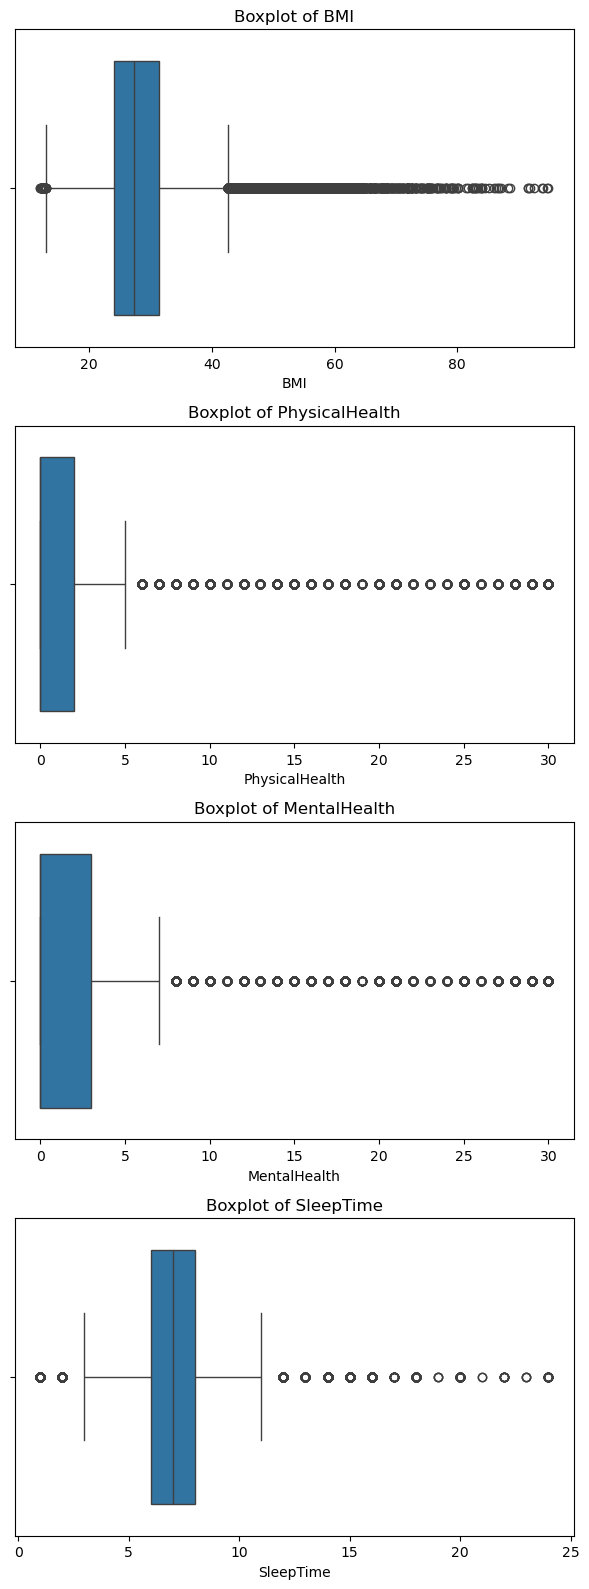

In [8]:
num_col = len(numerical_features)
fig, axes = plt.subplots(nrows=num_col, ncols=1, figsize=(6, 4*num_col))

if num_col == 1:
    axes = [axes]

for i, column in enumerate(numerical_features):
    sns.boxplot(x=df[column], ax=axes[i])
    axes[i].set_title(f"Boxplot of {column}")

plt.tight_layout()
plt.show()

Imputation of outliers.
----

In [9]:
for col in numerical_features:
    Q1=df[col].quantile(0.25)#1st quartile.
    Q3=df[col].quantile(0.75)#3rd quartile.
    
    IQR=Q3-Q1
    
    Lower_bound=Q1-1.5*IQR
    Upper_bound=Q3+1.5*IQR
    
    #Median without using outliers.
    median_value=df[(df[col]>=Lower_bound) & (df[col]<=Upper_bound)][col].median()
    
    #Apply transformation only to the current column.
    df[col]=df[col].apply(lambda x:median_value if x<Lower_bound or x>Upper_bound else x)

In [10]:
#Check the null values.
df.isnull().sum()

HeartDisease            0
BMI                 14710
Smoking             10233
AlcoholDrinking         0
Stroke                  0
PhysicalHealth      14710
MentalHealth            0
DiffWalking         10233
Sex                 15989
AgeCategory             0
Race                    0
Diabetic            14710
PhysicalActivity        0
GenHealth           15989
SleepTime               0
Asthma              10233
KidneyDisease           0
SkinCancer          15989
dtype: int64

In [11]:
# Create missing summary
missing_summary = pd.DataFrame({
    'Missing Count': df.isna().sum(),
    'Missing Percent': (df.isna().sum() / len(df)) * 100
})

# Keep only columns with MissingCount > 0
missing_summary = missing_summary[missing_summary['Missing Count'] > 0]

print(missing_summary.sort_values(by='Missing Percent', ascending=False))
#This is very good —missingness is actually low (3–5%) so we can impute it.
#If missing data is <5% then its safe to impute missing values with mean and median.

                Missing Count  Missing Percent
Sex                     15989         4.999765
SkinCancer              15989         4.999765
GenHealth               15989         4.999765
BMI                     14710         4.599822
PhysicalHealth          14710         4.599822
Diabetic                14710         4.599822
Smoking                 10233         3.199862
DiffWalking             10233         3.199862
Asthma                  10233         3.199862


Fill missing values.
----

There are outliers present in the data, so the missing values in numeric columns were imputed using the median.

In [12]:
# numerical columns with missing
num_cols = ['BMI','PhysicalHealth']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [13]:
#Change data type.
df[num_cols]=df[num_cols].astype(int)

In [14]:
# categorical columns with missing
cat_cols = ['Smoking','DiffWalking','Sex','GenHealth','Asthma','SkinCancer','Diabetic']

#first fill with np.nan then impute that values.
for col in cat_cols:
    df[col]=df[col].replace(r'^\s*$',np.nan,regex=True)

#Fill these values with mode.
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


In [15]:
df[cat_cols]=df[cat_cols].astype("object")

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  int64  
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  int64  
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

Feature Engineering
----

In the Age Category feature, there were too many small bins, so I grouped them into broader categories — Young, Middle-aged, and Older. This transformation helps reduce the number of categories, lowering the risk of overfitting and making the feature easier to interpret for the model.

In [17]:
#AgeCategory

# Define mapping to fewer categories
age_mapping = {
    '18-24': 'Young',
    '25-29': 'Young',
    '30-34': 'Young',
    '35-39': 'Young',
    '40-44': 'Middle-aged',
    '45-49': 'Middle-aged',
    '50-54': 'Middle-aged',
    '55-59': 'Middle-aged',
    '60-64': 'Older',
    '65-69': 'Older',
    '70-74': 'Older',
    '75-79': 'Older',
    '80 or older': 'Older'
}

df['AgeGroup'] = df['AgeCategory'].map(age_mapping)

df.drop(["AgeCategory"],axis=1,inplace=True)

In the Diabetic column, there were four categories. Two of them — ‘No, borderline diabetes’ and ‘Yes (during pregnancy)’ had very few observations. To simplify the feature and avoid sparse categories that could lead to model instability, I combined the values into just two categories: Yes and No. This reduces noise, helps prevent overfitting, and makes the model’s interpretation easier

In [18]:
print("Before change categories:",df["Diabetic"].value_counts())

#Map to Yes and No.
df["Diabetic"]=df["Diabetic"].replace({"No, borderline diabetes":"No","Yes (during pregnancy)":"Yes"})    
print("After map categories:",df["Diabetic"].value_counts())

Before change categories: Diabetic
No                         271966
Yes                         38905
No, borderline diabetes      6477
Yes (during pregnancy)       2447
Name: count, dtype: int64
After map categories: Diabetic
No     278443
Yes     41352
Name: count, dtype: int64


In [19]:
#All numerical columns.
numerical_features=[col for col in df if df[col].dtype!="O"]
print("Numerical_features: ",numerical_features)

print("=="*40)

#All Categorical features.
categorical_feature=[col for col in df.columns if df[col].dtype=="O"]
categorical_feature.remove("HeartDisease")
print("categorical_features: ",categorical_feature)

Numerical_features:  ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
categorical_features:  ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'Race', 'Diabetic', 'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease', 'SkinCancer', 'AgeGroup']


Data Visulization
-----

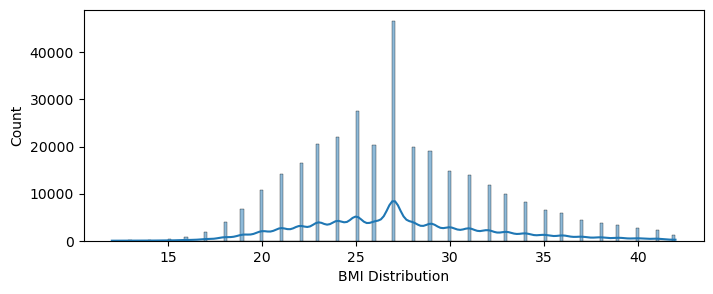

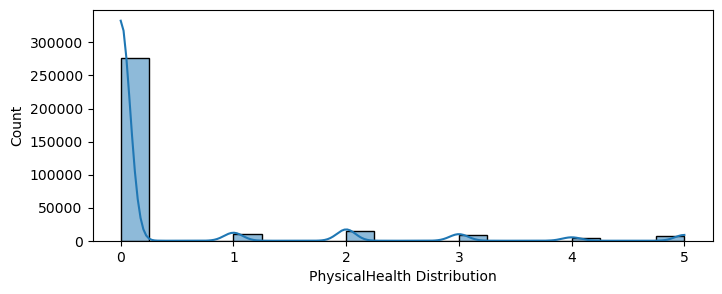

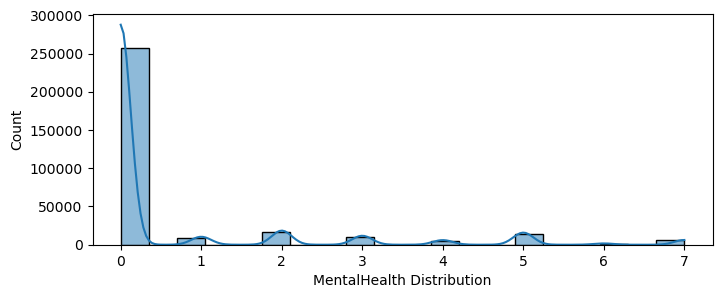

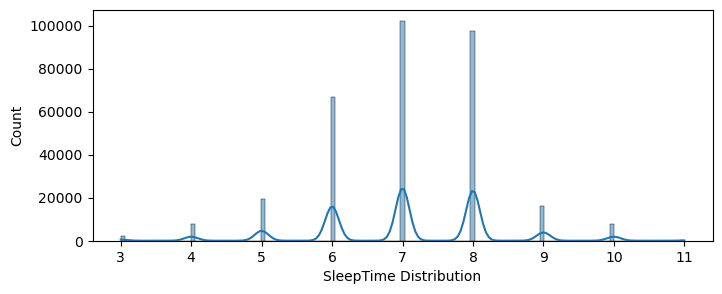

In [20]:
# Numeric variable distribution
for col in numerical_features:
    plt.subplots(figsize=(8,3))
    sns.histplot(data=df,x=col,kde=True)
    plt.xlabel(col+" Distribution")
    plt.show()

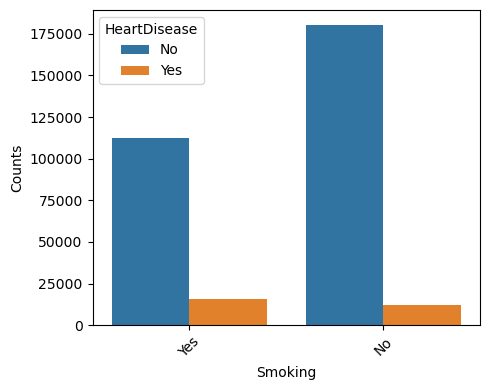

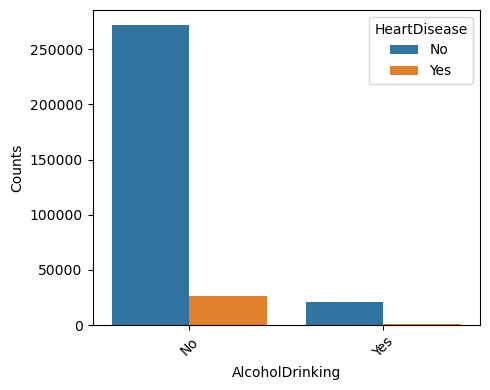

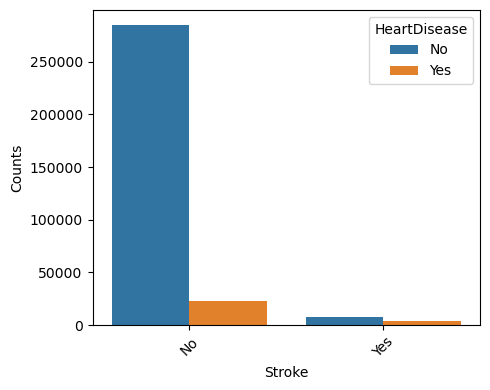

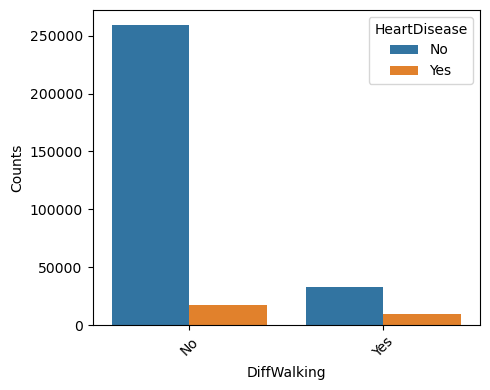

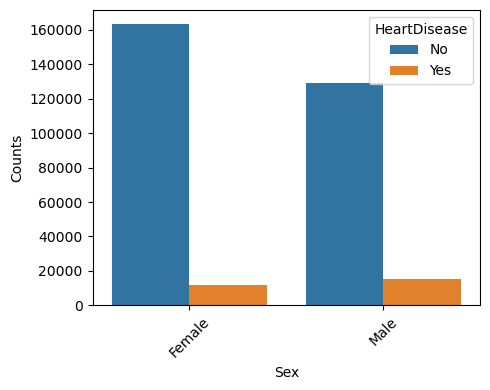

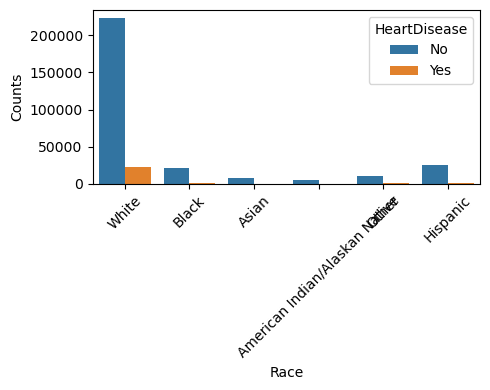

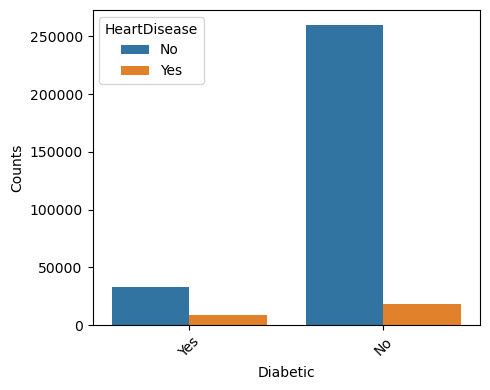

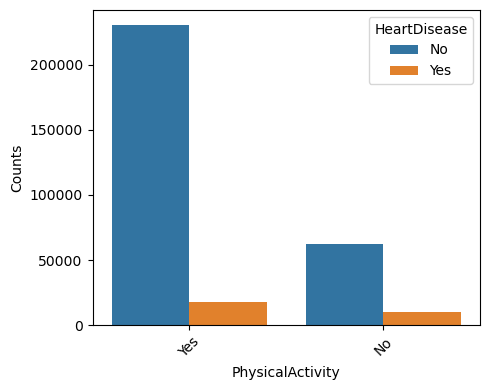

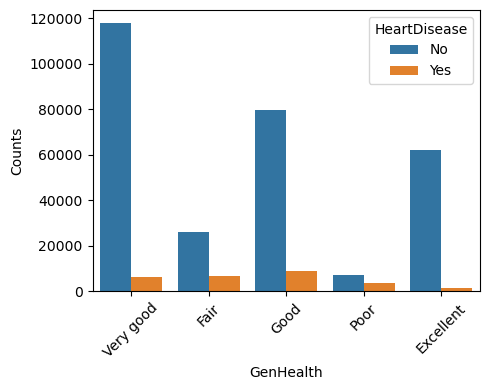

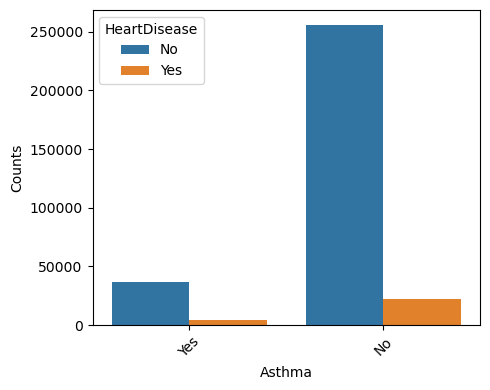

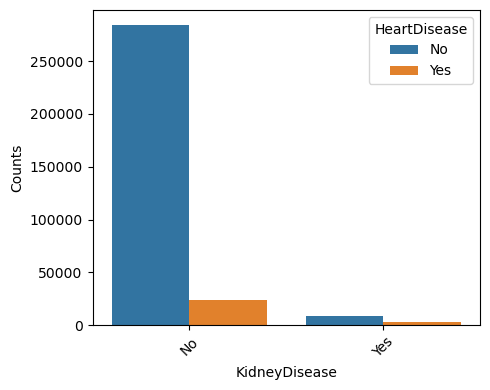

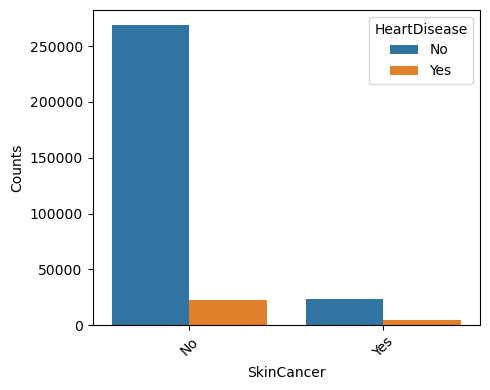

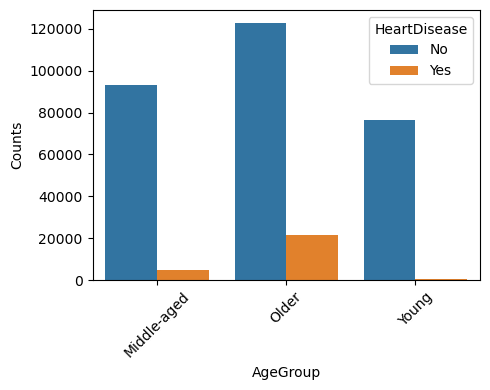

In [21]:
#For categorical feature.
for col in categorical_feature:
    plt.subplots(figsize=(5,4))
    #df[col].value_counts().plot(kind="bar")
    sns.countplot(data=df,x=col,hue='HeartDisease')
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Counts")
    plt.tight_layout()
    plt.show()

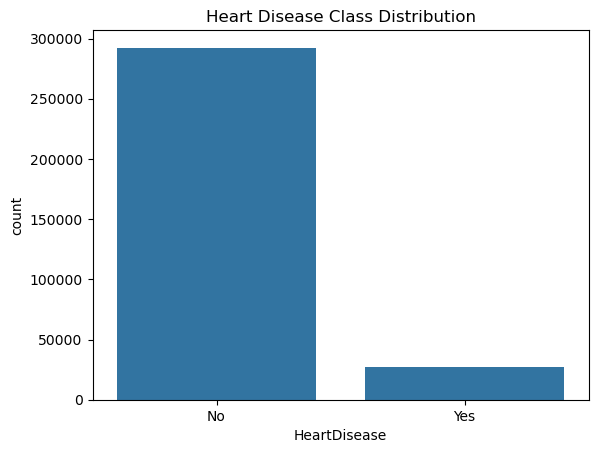

In [22]:
# Plot target distribution
sns.countplot(data=df, x='HeartDisease')
plt.title('Heart Disease Class Distribution')
plt.show()

In [23]:
#Check value counts for all cataegorical columns.
for col in categorical_feature:
    print("column name:",df[col].value_counts(),"\n")

column name: Smoking
No     192122
Yes    127673
Name: count, dtype: int64 

column name: AlcoholDrinking
No     298018
Yes     21777
Name: count, dtype: int64 

column name: Stroke
No     307726
Yes     12069
Name: count, dtype: int64 

column name: DiffWalking
No     276837
Yes     42958
Name: count, dtype: int64 

column name: Sex
Female    175438
Male      144357
Name: count, dtype: int64 

column name: Race
White                             245212
Hispanic                           27446
Black                              22939
Other                              10928
Asian                               8068
American Indian/Alaskan Native      5202
Name: count, dtype: int64 

column name: Diabetic
No     278443
Yes     41352
Name: count, dtype: int64 

column name: PhysicalActivity
Yes    247957
No      71838
Name: count, dtype: int64 

column name: GenHealth
Very good    124140
Good          88520
Excellent     63480
Fair          32891
Poor          10764
Name: count, dtype: int

In [24]:
#Create new data frame.
new_data=df[numerical_features+categorical_feature+["HeartDisease"]]
new_data

,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,Race,Diabetic,PhysicalActivity,GenHealth,Asthma,KidneyDisease,SkinCancer,AgeGroup,HeartDisease
0,16,3,0.0,5.0,Yes,No,No,No,Female,White,Yes,Yes,Very good,Yes,No,No,Middle-aged,No
1,20,0,0.0,7.0,No,No,Yes,No,Female,White,No,Yes,Very good,No,No,No,Older,No
2,26,0,0.0,8.0,Yes,No,No,No,Male,White,Yes,Yes,Fair,Yes,No,No,Older,No
3,24,0,0.0,6.0,No,No,No,No,Female,White,No,No,Good,No,No,Yes,Older,No
4,23,0,0.0,8.0,No,No,No,Yes,Female,White,No,Yes,Very good,No,No,No,Middle-aged,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,27,0,0.0,6.0,Yes,No,No,Yes,Male,Hispanic,Yes,No,Fair,Yes,No,No,Older,Yes
319791,29,0,0.0,5.0,Yes,No,No,No,Male,Hispanic,No,Yes,Very good,Yes,No,No,Young,No
319792,24,0,0.0,6.0,No,No,No,No,Female,Hispanic,No,Yes,Good,No,No,No,Middle-aged,No
319793,32,0,0.0,7.0,No,No,No,No,Female,Hispanic,No,No,Good,No,No,No,Young,No


In [25]:
new_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   BMI               319795 non-null  int64  
 1   PhysicalHealth    319795 non-null  int64  
 2   MentalHealth      319795 non-null  float64
 3   SleepTime         319795 non-null  float64
 4   Smoking           319795 non-null  object 
 5   AlcoholDrinking   319795 non-null  object 
 6   Stroke            319795 non-null  object 
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   Race              319795 non-null  object 
 10  Diabetic          319795 non-null  object 
 11  PhysicalActivity  319795 non-null  object 
 12  GenHealth         319795 non-null  object 
 13  Asthma            319795 non-null  object 
 14  KidneyDisease     319795 non-null  object 
 15  SkinCancer        319795 non-null  object 
 16  AgeGroup          31

One-hot encoding/Categorical Encoding.
---

In [26]:
cat_feature=['Smoking','AlcoholDrinking','Stroke','DiffWalking','PhysicalActivity','Asthma','KidneyDisease','SkinCancer','HeartDisease','Diabetic']

In [27]:
#created function to replace categories of yes,no.
def create_features(x):
    return x.map({"Yes":1,"No":0})

new_data[cat_feature]=new_data[cat_feature].apply(create_features)

In [28]:
new_data["Sex"]=new_data["Sex"].map({"Female":0,"Male":1})
new_data["AgeGroup"]=new_data["AgeGroup"].map({"Older":2,"Middle-aged":1,"Young":0})

In [29]:
new_data.columns

Index(['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'Smoking',
       'AlcoholDrinking', 'Stroke', 'DiffWalking', 'Sex', 'Race', 'Diabetic',
       'PhysicalActivity', 'GenHealth', 'Asthma', 'KidneyDisease',
       'SkinCancer', 'AgeGroup', 'HeartDisease'],
      dtype='object')

In [30]:
#Dummification.
new_data=pd.get_dummies(new_data,columns=["Race","GenHealth"],drop_first=True,dtype=int)
new_data.head()

,BMI,PhysicalHealth,MentalHealth,SleepTime,Smoking,AlcoholDrinking,Stroke,DiffWalking,Sex,Diabetic,...,HeartDisease,Race_Asian,Race_Black,Race_Hispanic,Race_Other,Race_White,GenHealth_Fair,GenHealth_Good,GenHealth_Poor,GenHealth_Very good
0,16,3,0.0,5.0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,1
1,20,0,0.0,7.0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,1
2,26,0,0.0,8.0,1,0,0,0,1,1,...,0,0,0,0,0,1,1,0,0,0
3,24,0,0.0,6.0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,0
4,23,0,0.0,8.0,0,0,0,1,0,0,...,0,0,0,0,0,1,0,0,0,1


Train Test Split And Model Training
----

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay, \
                            precision_score, recall_score, f1_score, roc_auc_score,roc_curve 


#Split the data into x and y.
X = new_data.drop(['HeartDisease'], axis=1)
y = new_data['HeartDisease']

# separate dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
scaler=MinMaxScaler()#Normalise the range of independent variables in dataset.
X_train[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features]=scaler.transform(X_test[numerical_features])

print(X_train.shape)
print(X_test.shape)

(255836, 24)
(63959, 24)


Feature Selection : Pearsons Correlation method.
---

Feature correlations were analyzed using a heatmap. Since no strong correlations were observed, all features were retained, ensuring no loss of information while minimizing redundancy. Additionally for feature selection, a function was used to check for any feature pairs with a correlation threshold greater than 0.9, but no such highly correlated features were found, so none were dropped from the dataset.

<Axes: >

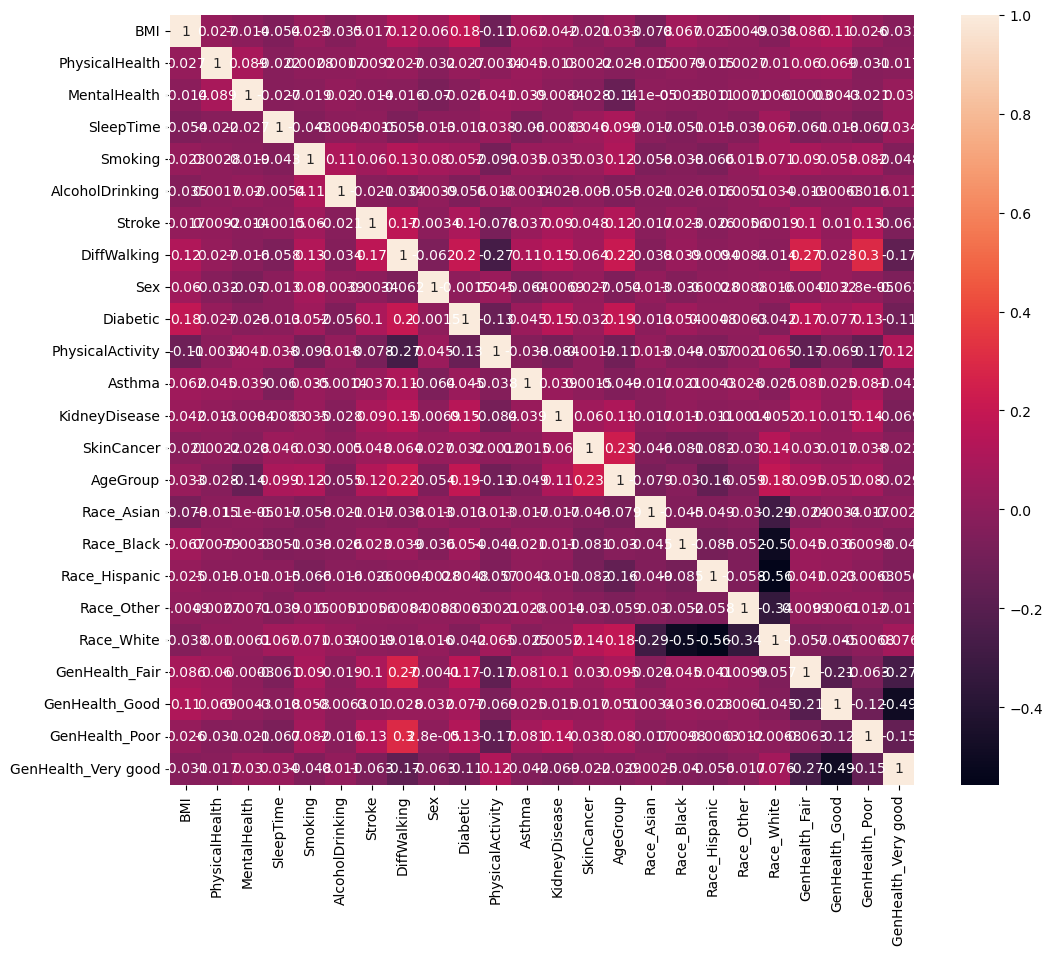

In [32]:
plt.figure(figsize=(12,10))
sns.heatmap(X_train.corr(),annot=True)

In [34]:
# with the following function we can select highly correlated features
# it will remove the first feature that is correlated with anything other feature

def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of correlated columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold: # we are interested in absolute coeff value
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

corr_features = correlation(X_train, 0.9)#Set threshold 0.7 here.
print("Number of highly correlated features:",len(set(corr_features)))

Number of highly correlated features: 0


In [35]:
corr_features

set()

Feature Selection-Information gain - mutual information
---

<Axes: >

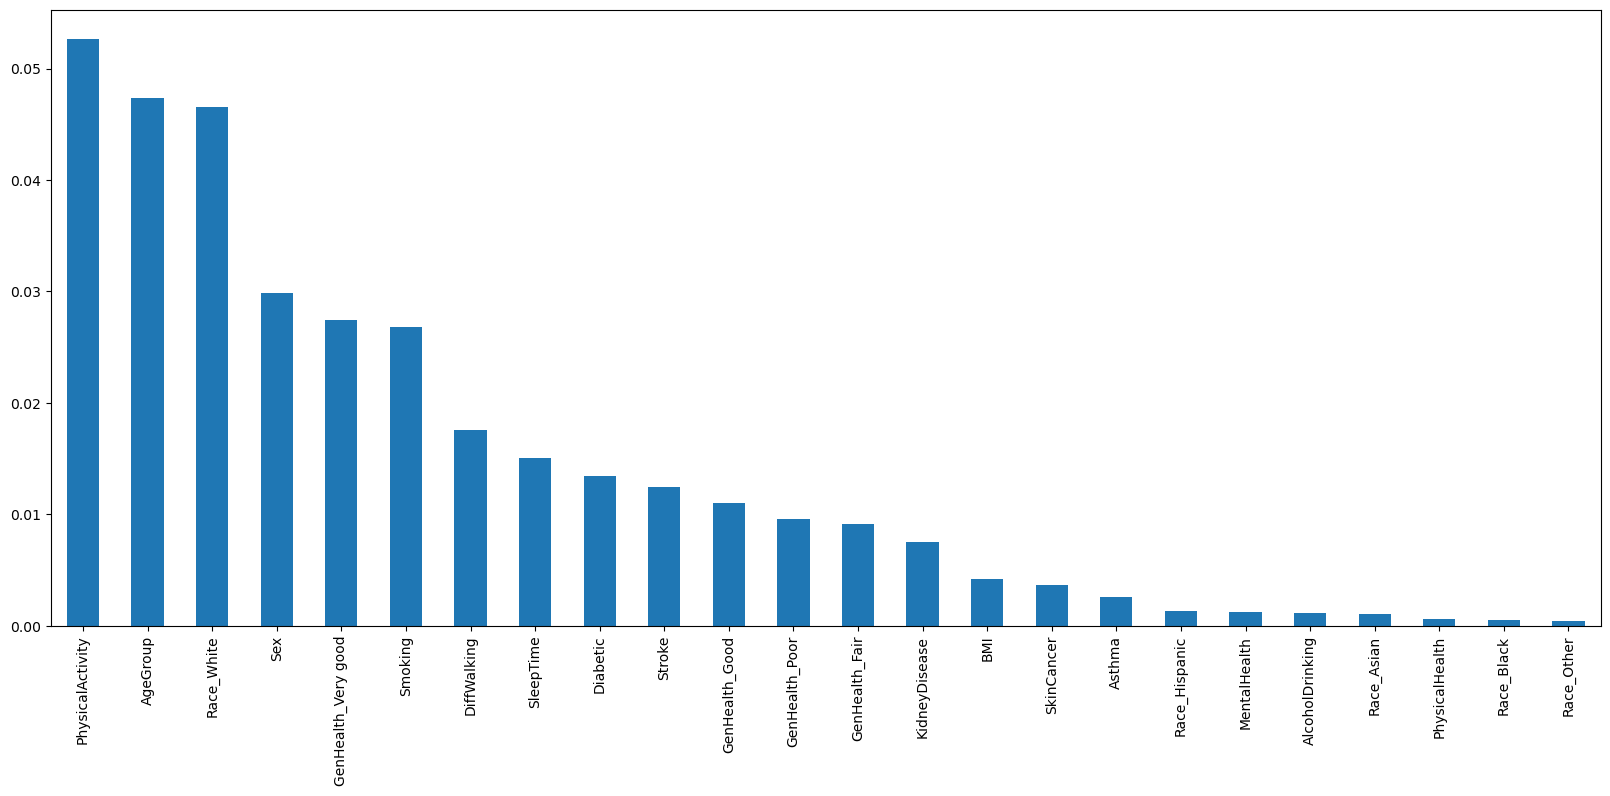

In [36]:
from sklearn.feature_selection import mutual_info_classif

# determine the mutual information
mutual_info = mutual_info_classif(X_train, y_train)

mutual_info = pd.Series(mutual_info)
mutual_info.index = X_train.columns
mutual_info.sort_values(ascending=False)

#let's plot the ordered mutual_info values per feature
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 8))


In [37]:
from sklearn.feature_selection import SelectKBest

#We Will select the  top 15 important features
sel_fift_cols = SelectKBest(mutual_info_classif, k=15)
sel_fift_cols.fit(X_train, y_train)
X_train.columns[sel_fift_cols.get_support()]

Index(['BMI', 'SleepTime', 'Smoking', 'Stroke', 'DiffWalking', 'Sex',
       'Diabetic', 'PhysicalActivity', 'KidneyDisease', 'AgeGroup',
       'Race_White', 'GenHealth_Fair', 'GenHealth_Good', 'GenHealth_Poor',
       'GenHealth_Very good'],
      dtype='object')

In [38]:
#Get top feature names.
top_features = X_train.columns[sel_fift_cols.get_support()]

#Select the columns for training and testing.
X_train_selected = X_train[top_features]
X_test_selected = X_test[top_features]

In [39]:
X_train_selected.columns

Index(['BMI', 'SleepTime', 'Smoking', 'Stroke', 'DiffWalking', 'Sex',
       'Diabetic', 'PhysicalActivity', 'KidneyDisease', 'AgeGroup',
       'Race_White', 'GenHealth_Fair', 'GenHealth_Good', 'GenHealth_Poor',
       'GenHealth_Very good'],
      dtype='object')

In [40]:
#The target variable is not balanced, so it needs to be balanced.
y_train.value_counts()

HeartDisease
0    234055
1     21781
Name: count, dtype: int64

In [41]:
weight = {0:1, 1:11}

#For XGboost classifier,compute scale_pos_weight = (# negative samples) / (# positive samples)
scale_pos_weight = np.sum(y_train==0) / np.sum(y_train==1)
scale_pos_weight

np.float64(10.745833524631559)

In [42]:
# from imblearn.over_sampling import SMOTE

# smote = SMOTE(random_state=42)
# X_train, y_train= smote.fit_resample(X_train, y_train)

# print("After SMOTE:", y_train.value_counts().to_dict())

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [44]:
models = {"Logistic Regression": LogisticRegression(max_iter=1000, class_weight=weight),

           "Decision Tree": DecisionTreeClassifier(splitter='best', max_features=None, max_depth=10,criterion='gini', class_weight='balanced'),

           "Random Forest": RandomForestClassifier(n_estimators=500, min_samples_split=8, max_features=7,max_depth=None, class_weight='balanced'),

            # GradientBoostingClassifier does NOT support class_weight directly.
            # You either need to upsample your training set (SMOTE) or try HistGradientBoosting.
           "Gradient Boost": GradientBoostingClassifier(n_estimators=300, learning_rate=0.2, max_depth=7,min_samples_split=2, min_samples_leaf=4,
                             subsample=1.0, max_features='log2'),

            # AdaBoost also doesn’t take class_weight directly, but you can wrap base_estimator.
            "Adaboost": AdaBoostClassifier(),

            "XGBoost": XGBClassifier(n_estimators=100, max_depth=30, learning_rate=0.1,colsample_bytree=1.0, use_label_encoder=False,
                        eval_metric='logloss', scale_pos_weight=scale_pos_weight)}


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_selected, y_train) # Train model
    
    # Make predictions
    y_train_pred = model.predict(X_train_selected)
    y_test_pred = model.predict(X_test_selected)
    
    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)
    
    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc
    
    print(list(models.keys())[i])
    
    print('Model performance for Training set')
    print(f'- Accuracy: {model_train_accuracy}')
    print(f'- Confusion matrix:\n {conf_matrix_train}')
    print(f'\n - F1 score: {model_train_f1}')
    print(f'- Precision: {model_train_precision}')
    print(f'- Recall: {model_train_recall}')
    print(f'- Roc Auc Score: {model_train_rocauc_score}')
    
    print('----------------------------------')
    
    print('Model performance for Test set')
    print(f'- Accuracy: {model_test_accuracy}')
    print(f'- Confusion matrix:\n {conf_matrix_test}')
    print(f'\n - F1 score: {model_test_f1}')
    print(f'- Precision: {model_test_precision}')
    print(f'- Recall: {model_test_recall}')
    print(f'- Roc Auc Score: {model_test_rocauc_score}')

    print('='*35)
    print("\n")


Logistic Regression
Model performance for Training set
- Accuracy: 0.7359284854359824
- Confusion matrix:
 [[171533  62522]
 [  5037  16744]]

 - F1 score: 0.7925585915531872
- Precision: 0.21123810965609466
- Recall: 0.7687434002111933
- Roc Auc Score: 0.7508090759360638
----------------------------------
Model performance for Test set
- Accuracy: 0.735221000953736
- Confusion matrix:
 [[42750 15617]
 [ 1318  4274]]

 - F1 score: 0.7910269106862049
- Precision: 0.21487104720727968
- Recall: 0.7643061516452074
- Roc Auc Score: 0.7483702876032332


Decision Tree
Model performance for Training set
- Accuracy: 0.7282634187526384
- Confusion matrix:
 [[168960  65095]
 [  4425  17356]]

 - F1 score: 0.7871163404688989
- Precision: 0.21050078228281038
- Recall: 0.7968412836876176
- Roc Auc Score: 0.7593614463555688
----------------------------------
Model performance for Test set
- Accuracy: 0.7227911630888538
- Confusion matrix:
 [[41978 16389]
 [ 1341  4251]]

 - F1 score: 0.78179028631069

Logistic Regression: High recall, good generalization, low precision.

Decision Tree: Slightly worse than LR.

Random Forest: Overfitting, poor recall.

Gradient Boost: Very low recall.

AdaBoost: Very low recall.

XGBoost: Overfitting, poor recall

ROC Curve:
----

Accuracy : 0.735221000953736
Recall : 0.7643061516452074
Confusion Matrix :
 [[42750 15617]
 [ 1318  4274]]
ROC AUC Score : 0.82288564456472


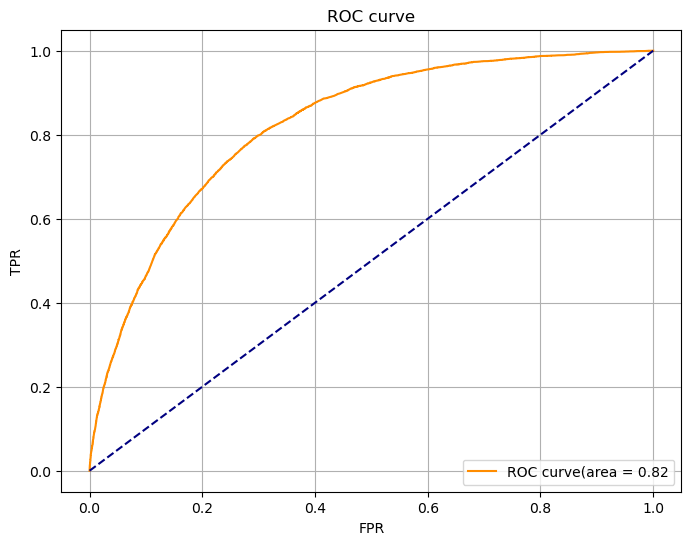

In [45]:
weight = {0:1, 1:11}
lr = LogisticRegression(class_weight=weight)
model = lr.fit(X_train_selected, y_train)
lr_predict = lr.predict(X_test_selected)
lr_predict_proba = lr.predict_proba(X_test_selected)[:, 1]#all rows and 2nd columns
lr_acc = accuracy_score(y_test, lr_predict)
lr_recall = recall_score(y_test, lr_predict)
conf_matrix = confusion_matrix(y_test, lr_predict)
lr_roc_auc = roc_auc_score(y_test,lr_predict_proba)
print("Accuracy :", lr_acc)
print("Recall :", lr_recall)
print("Confusion Matrix :\n", conf_matrix)
print("ROC AUC Score :", lr_roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, lr_predict_proba)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color = 'darkorange', label = f"ROC curve(area = {lr_roc_auc:.2f}")
plt.plot([0,1],[0,1],color = 'navy', linestyle='--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC curve")
plt.legend(loc='lower right')
plt.grid()
plt.show()

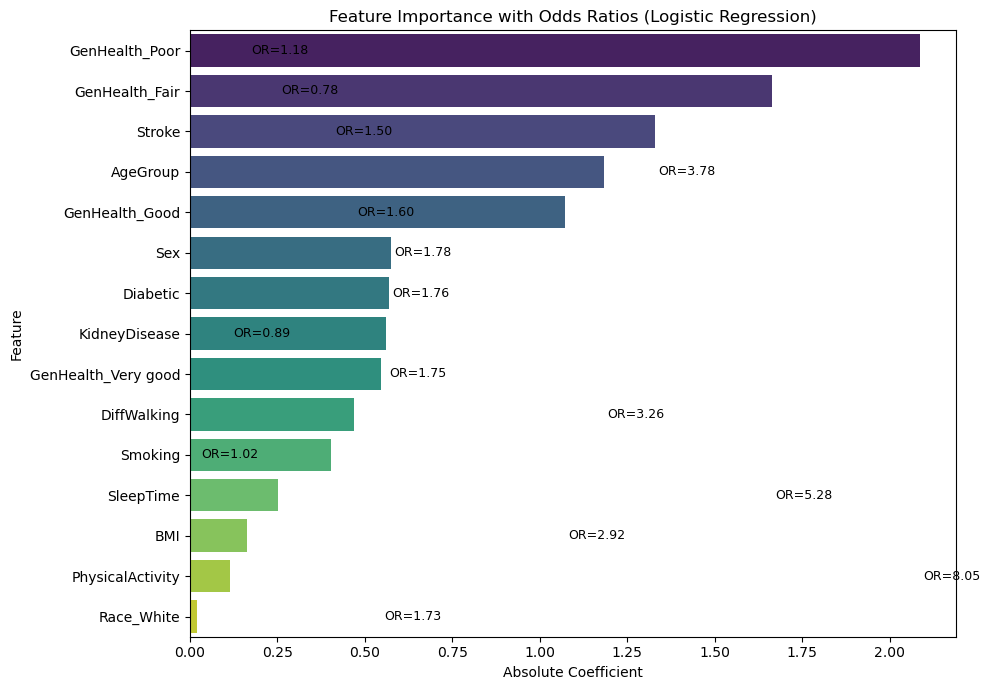

In [58]:
# Fit logistic regression
log_reg = LogisticRegression(class_weight=weight, max_iter=1000)
log_reg.fit(X_train_selected, y_train)

# Prepare feature importance
coefficients = log_reg.coef_[0]
features = X_train_selected.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients),
    'Odds_Ratio': np.exp(coefficients)
})

# Sort by absolute coefficient descending (largest first)
feature_importance.sort_values('Abs_Coefficient', ascending=False, inplace=True)

# Plot
plt.figure(figsize=(10, 7))
sns.barplot(
    x='Abs_Coefficient',
    y='Feature',
    data=feature_importance,
    palette='viridis',
    order=feature_importance['Feature']  # keep our sorted order
)

# Annotate bars with Odds Ratios
for index, row in feature_importance.iterrows():
    plt.text(row['Abs_Coefficient'] + 0.01, index, f"OR={row['Odds_Ratio']:.2f}",
             va='center', fontsize=9)

plt.title('Feature Importance with Odds Ratios (Logistic Regression)')
plt.xlabel('Absolute Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [ ]:
#Smote technique.

In [49]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_selected, y_train= smote.fit_resample(X_train_selected, y_train)

print("After SMOTE:", y_train.value_counts().to_dict())

After SMOTE: {0: 234055, 1: 234055}


In [50]:
from sklearn.model_selection import RandomizedSearchCV

# ---------------- PARAMETER GRIDS ---------------- #
#  Decision Tree
dt_params = {'criterion': ['gini','entropy','log_loss'],
    'splitter': ['best','random'],
    'max_depth': [1,2,3,4,5,10],
    'max_features': ['sqrt','log2', None]}

#  Random Forest
rf_params = {'max_depth': [5, 8, 15, None, 10],
    'max_features': [5, 7, 'sqrt', 'log2', None],
    'min_samples_split': [2, 8, 15, 20],
    'n_estimators': [100, 200, 500, 1000]}

#  XGBoost
xgb_params = {'learning_rate': [0.1, 0.01],
    'max_depth': [5, 8, 12, 20, 30],
    'n_estimators': [100, 200, 300],
    'colsample_bytree': [0.3, 0.4, 0.5, 0.8, 1.0]}

# ---------------- LIST OF MODELS ---------------- #

randomcv_models = [ ("DT", DecisionTreeClassifier(), dt_params),
    ("RF", RandomForestClassifier(), rf_params),
    ("XGBoost", XGBClassifier(use_label_encoder=False, eval_metric='logloss'), xgb_params)]

# ---------------- RUN RANDOMIZEDSEARCH ---------------- #
model_param = {}

for name, model, params in randomcv_models:
    print(f"\nRunning RandomizedSearchCV for {name} ...")
    random = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=50,       # adjust to taste
        cv=3,
        scoring='roc_auc',  # or 'f1_weighted'
        verbose=2,
        n_jobs=-1,
        random_state=42
    )
    random.fit(X_train_selected, y_train)
    model_param[name] = random.best_params_

# ---------------- PRINT RESULTS ---------------- #

for model_name in model_param:
    print(f"\n---------------- Best Params for {model_name} -------------------")
    print(model_param[model_name])



Running RandomizedSearchCV for DT ...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Running RandomizedSearchCV for RF ...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

Running RandomizedSearchCV for XGBoost ...
Fitting 3 folds for each of 50 candidates, totalling 150 fits

---------------- Best Params for DT -------------------
{'splitter': 'best', 'max_features': None, 'max_depth': 10, 'criterion': 'log_loss'}

---------------- Best Params for RF -------------------
{'n_estimators': 500, 'min_samples_split': 8, 'max_features': 7, 'max_depth': None}

---------------- Best Params for XGBoost -------------------
{'n_estimators': 100, 'max_depth': 30, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [52]:
# ---------------- DEFINE ALL MODELS WITH BEST PARAMS ---------------- #
models = {"Decision Tree": DecisionTreeClassifier(splitter='best',max_features=None,max_depth=10,criterion='log_loss'),
    
          "Random Forest": RandomForestClassifier(n_estimators=500,min_samples_split=8,max_features=7,max_depth=None),
    
          "XGBoost": XGBClassifier(n_estimators=100,max_depth=30,learning_rate=0.1,colsample_bytree=1.0)
         }

for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train_selected, y_train) # Train model

    # Make predictions.
    y_train_pred = model.predict(X_train_selected)
    y_test_pred = model.predict(X_test_selected)

    # Training set performance.
    model_train_accuracy = accuracy_score(y_train, y_train_pred) # Calculate Accuracy
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted') # Calculate F1-score
    model_train_precision = precision_score(y_train, y_train_pred) # Calculate Precision
    model_train_recall = recall_score(y_train, y_train_pred) # Calculate Recall
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance.
    model_test_accuracy = accuracy_score(y_test, y_test_pred) # Calculate Accuracy
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted') # Calculate F1-score
    model_test_precision = precision_score(y_test, y_test_pred) # Calculate Precision
    model_test_recall = recall_score(y_test, y_test_pred) # Calculate Recall
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred) #Calculate Roc


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))
    
    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    

    print('----------------------------------')
    
    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    
    print('='*35)
    print('\n')

Decision Tree
Model performance for Training set
- Accuracy: 0.7685
- F1 score: 0.7683
- Precision: 0.7528
- Recall: 0.7995
- Roc Auc Score: 0.7685
----------------------------------
Model performance for Test set
- Accuracy: 0.7331
- F1 score: 0.7890
- Precision: 0.2054
- Recall: 0.7155
- Roc Auc Score: 0.7251


Random Forest
Model performance for Training set
- Accuracy: 0.9066
- F1 score: 0.9066
- Precision: 0.8994
- Recall: 0.9156
- Roc Auc Score: 0.9066
----------------------------------
Model performance for Test set
- Accuracy: 0.8250
- F1 score: 0.8466
- Precision: 0.2230
- Recall: 0.4033
- Roc Auc Score: 0.6343


XGBoost
Model performance for Training set
- Accuracy: 0.9017
- F1 score: 0.9017
- Precision: 0.9009
- Recall: 0.9027
- Roc Auc Score: 0.9017
----------------------------------
Model performance for Test set
- Accuracy: 0.8263
- F1 score: 0.8458
- Precision: 0.2095
- Recall: 0.3557
- Roc Auc Score: 0.6135


